# Financial Forecasting Dashboard

## Objective

This project demonstrates time-series forecasting using the ARIMA (AutoRegressive Integrated Moving Average) model.

The model is trained on historical sales data and predicts future values.

## Technologies

- Python
- Pandas
- NumPy
- Statsmodels
- Matplotlib

## Features

- Time-series forecasting
- ARIMA modelling
- Future sales prediction
- Statistical analysis
- Data visualisation

## Author

Parag Gupta

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [2]:
data = [100,102,105,107,110,112,115,118,120,123,
        125,128,130,133,135,138,140,143,145,148]

df = pd.DataFrame(data, columns=["Sales"])

print(df.head())

   Sales
0    100
1    102
2    105
3    107
4    110


In [3]:
model = ARIMA(df["Sales"], order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -17.344
Date:                Thu, 18 Jun 2026   AIC                             40.689
Time:                        18:05:19   BIC                             43.522
Sample:                             0   HQIC                            41.168
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.003    391.276      0.000       0.995       1.005
ma.L1         -0.9940     10.229     -0.097      0.923     -21.043      19.055
sigma2         0.2648      2.797      0.095      0.9

In [4]:
forecast = model_fit.forecast(steps=5)

print("Forecasted Values:")
print(forecast)

Forecasted Values:
20    150.520868
21    153.041734
22    155.562598
23    158.083460
24    160.604320
Name: predicted_mean, dtype: float64


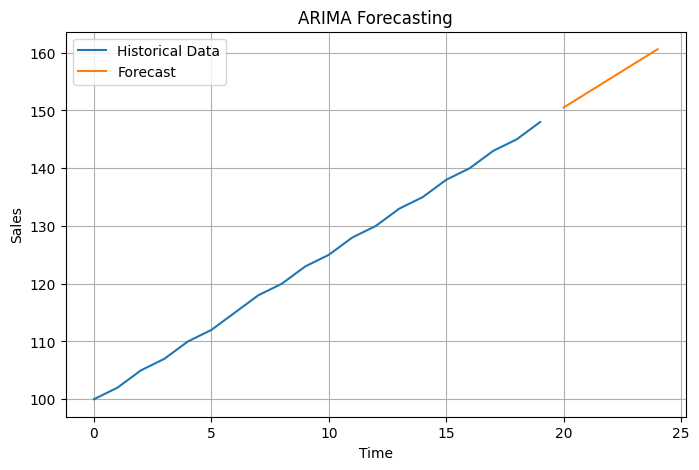

In [5]:
plt.figure(figsize=(8,5))

plt.plot(df["Sales"], label="Historical Data")

future_index = range(len(df), len(df)+5)

plt.plot(future_index, forecast,
         label="Forecast")

plt.legend()

plt.title("ARIMA Forecasting")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.grid(True)

plt.show()